In [1]:
# python
import sys
import os
import importlib
from coffea import processor

# columnar analysis
from coffea.nanoevents import NanoAODSchema
import awkward as ak   #numpy like module for handling arrays

# local
sys.path.insert(1, os.path.join(sys.path[0], '../../../')) # fixme: there must be a better way to handle this...
from sidm.tools import ffschema, sidm_processor, utilities, scaleout
# always reload local modules to pick up changes during development
importlib.reload(ffschema)  #why do we need this?
importlib.reload(sidm_processor) 
importlib.reload(utilities)

# plotting
import matplotlib.pyplot as plt
import mplhep as hep
import numpy as np
import hist
utilities.set_plot_style()
%matplotlib inline

In [2]:
samples = [
    # "2Mu2E_500GeV_5p0GeV_0p8mm",
    # "2Mu2E_500GeV_5p0GeV_40p0mm",
    "2Mu2E_500GeV_5p0GeV_8p0mm",
    # "2Mu2E_500GeV_5p0GeV_80p0mm",
    # "4Mu_1000GeV_0p25GeV_2p0mm"
]

# fileset = utilities.make_fileset(samples, "llpNanoAOD_v2", location_cfg="signal_v6.yaml")
fileset = utilities.make_fileset(samples, "llpNanoAOD_v2", max_files=1, location_cfg="signal_v6.yaml")

In [3]:
channels = ["baseNoLj",
            "muonID_loose",
           ]

runner = processor.Runner(
    executor=processor.IterativeExecutor(),
#     #executor=processor.FuturesExecutor(),
    schema=NanoAODSchema,
    maxchunks=1,
    skipbadfiles=True
)

p = sidm_processor.SidmProcessor(
    channels,
    ["muon_base",
     "muonID_base",
     ]
)

output = runner.run(fileset, treename='Events', processor_instance=p)
out = output["out"]

Output()

Output()

/opt/conda/lib/python3.9/site-packages/awkward/_connect/_numpy.py:195: RuntimeWarning: divide by zero encountered 
in divide
  result = getattr(ufunc, method)(

/opt/conda/lib/python3.9/site-packages/awkward/_connect/_numpy.py:195: RuntimeWarning: invalid value encountered in
divide
  result = getattr(ufunc, method)(

#--------------------------------------------------------------------------
#                         FastJet release 3.4.0
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           http://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------


In [4]:
ch1 = channels[0] #baseNoLj
ch2 = channels[1]

legsam = [s.split("_")[1] + "  " + s.split("_")[2] + "  " + s.split("_")[3] for s in samples]

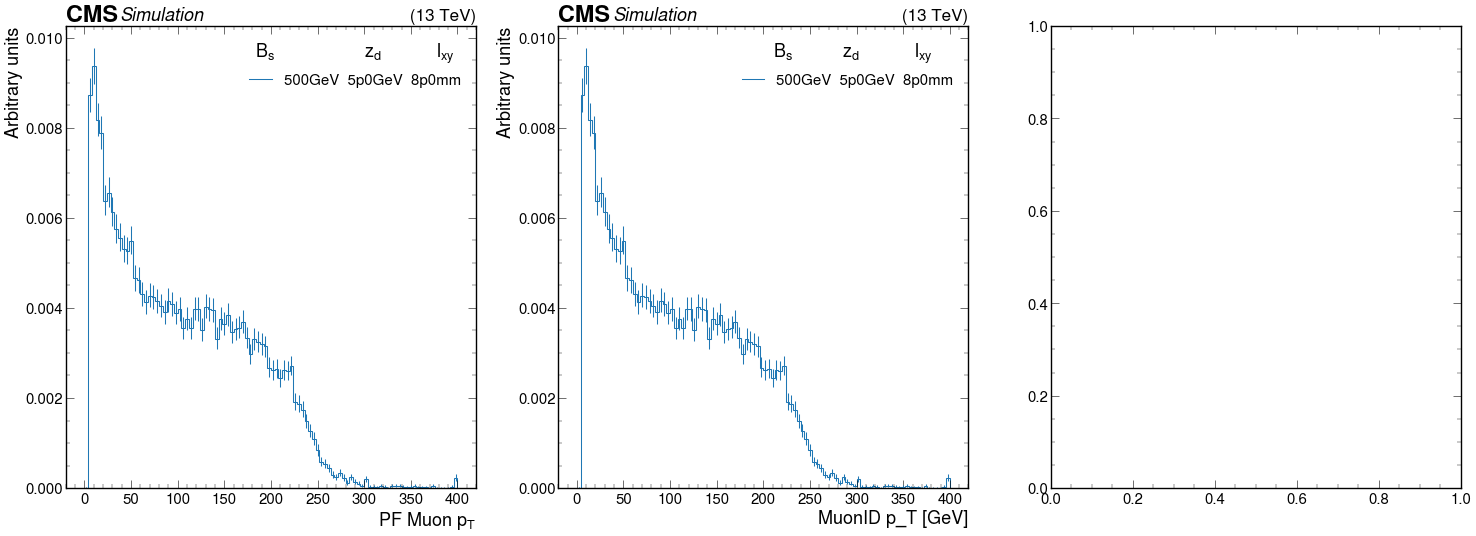

In [5]:
nplots = 3
plt.subplots(1, nplots, figsize=(nplots*12, 12))

plt.subplot(1, nplots, 1)
for sample in samples:
    utilities.plot(out[sample]["hists"]["muon_pt"][ch1, :], density=True,)
    plt.legend(legsam, title="$  B_s$ \t\t $z_d$ \t\t $l_{xy}$", alignment="center")
    #plt.ylim(0, 0.07)
    plt.ylabel("Arbitrary units")
    
plt.subplot(1, nplots, 2)
for sample in samples:
    utilities.plot(out[sample]["hists"]["muonID_pt"][ch2, :], density=True,)
    plt.legend(legsam, title="  $B_s$\t\t $z_d$ \t\t $l_{xy}$", alignment="center")
    #plt.ylim(0, 0.07)
    plt.ylabel("Arbitrary units")
    
# plt.subplot(1, nplots, 3)
# for sample in samples:
#     utilities.plot(out[sample]["hists"]["muon_isTracker_pt"][ch1, :], density=True,)
#     plt.legend(legsam, title="  $B_s$\t\t $z_d$ \t\t $l_{xy}$", alignment="center")
#     #plt.ylim(0, 0.07)
#     plt.ylabel("Arbitrary units")

In [6]:
# nplots = 2
# plt.subplots(1, nplots, figsize=(nplots*12, 12))

# plt.subplot(1, nplots, 1)
# for sample in samples:
#     utilities.plot(out[sample]["hists"]["muon_isGlobal_pt"][ch1, :], density=True,)
#     plt.legend(legsam, title="$B_s$ \t\t $z_d$ \t\t $l_{xy}$", alignment="center")
#     #plt.ylim(0, 0.07)
#     plt.ylabel("Arbitrary units")
    
# plt.subplot(1, nplots, 2)
# for sample in samples:
#     utilities.plot(out[sample]["hists"]["muon_isTracker_pt"][ch2, :], density=True,)
#     plt.legend(legsam, title="  $B_s$\t\t $z_d$ \t\t $l_{xy}$", alignment="center")
#     #plt.ylim(0, 0.07)
#     plt.ylabel("Arbitrary units")